In [1]:
# Cellule 1 - Imports et configuration
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from datetime import datetime

# Charger la cle API depuis le fichier .env
load_dotenv()
API_KEY = os.getenv("API_KEY")

print("Bibliotheques importees avec succes")
print(f"Cle API chargee : {API_KEY[:6]}...") if API_KEY else print("Cle API non trouvee")

Bibliotheques importees avec succes
Cle API chargee : 30bb2a...


In [2]:
# Cellule 2 - Recuperer les donnees de qualite de l'air a Dakar
def get_air_quality(api_key):
    lat = 14.6937
    lon = -17.4441
    
    url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={api_key}"
    
    response = requests.get(url)
    data = response.json()
    
    return data

data = get_air_quality(API_KEY)
print("Donnees recues avec succes")
print(f"Statut de la reponse : {data}")

Donnees recues avec succes
Statut de la reponse : {'coord': {'lon': -17.4441, 'lat': 14.6937}, 'list': [{'main': {'aqi': 4}, 'components': {'co': 107.43, 'no': 0.05, 'no2': 0.4, 'o3': 89.68, 'so2': 1.14, 'pm2_5': 40.78, 'pm10': 187.92, 'nh3': 0.1}, 'dt': 1778594053}]}


In [3]:
# Cellule 3 - Recuperer l'historique sur 5 jours
import time

def get_air_quality_history(api_key):
    lat = 14.6937
    lon = -17.4441
    
    end = int(time.time())
    start = end - (5 * 24 * 3600)
    
    url = f"http://api.openweathermap.org/data/2.5/air_pollution/history?lat={lat}&lon={lon}&start={start}&end={end}&appid={api_key}"
    
    response = requests.get(url)
    data = response.json()
    
    records = []
    for item in data['list']:
        records.append({
            'datetime': datetime.fromtimestamp(item['dt']),
            'aqi': item['main']['aqi'],
            'co': item['components']['co'],
            'no2': item['components']['no2'],
            'o3': item['components']['o3'],
            'so2': item['components']['so2'],
            'pm2_5': item['components']['pm2_5'],
            'pm10': item['components']['pm10'],
        })
    
    df = pd.DataFrame(records)
    return df

df = get_air_quality_history(API_KEY)
print(f"Nombre de mesures recuperees : {len(df)}")
print(df.head())

Nombre de mesures recuperees : 120
             datetime  aqi     co   no2     o3   so2  pm2_5   pm10
0 2026-05-07 14:00:00    2  98.92  0.34  68.21  0.86   9.98  26.00
1 2026-05-07 15:00:00    2  98.21  0.34  69.15  0.85   9.68  25.54
2 2026-05-07 16:00:00    2  97.89  0.37  69.35  0.84   9.21  24.59
3 2026-05-07 17:00:00    2  97.78  0.44  68.72  0.82   8.71  23.52
4 2026-05-07 18:00:00    2  97.94  0.56  68.47  0.83   8.59  23.59


Donnees sauvegardees dans data/dakar_air_quality.csv


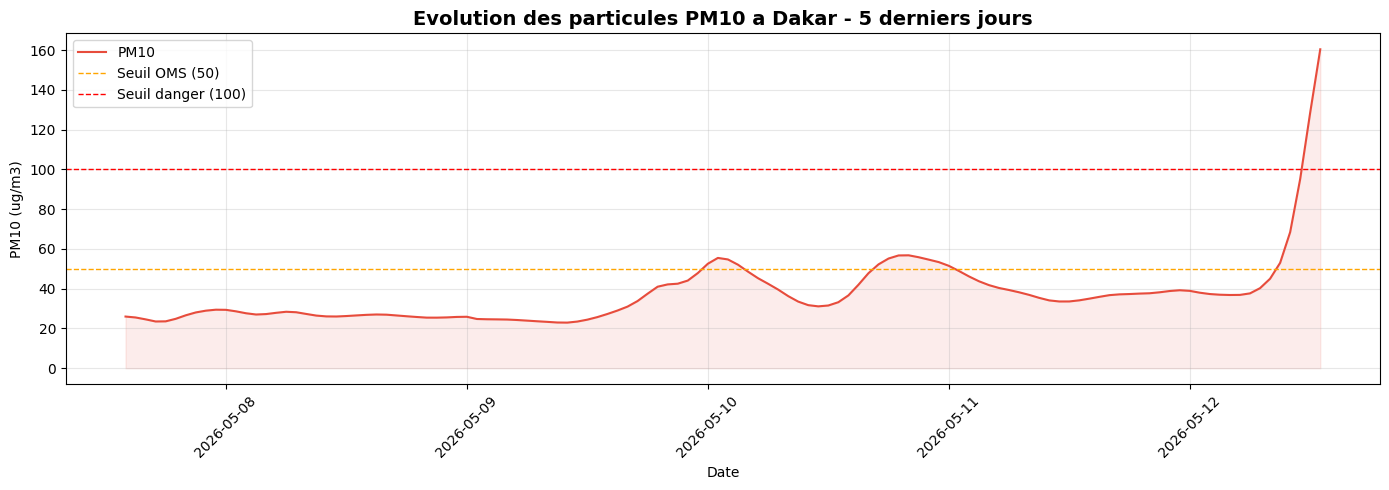

Graphique sauvegarde dans visuals/pm10_evolution.png


In [4]:
# Cellule 4 - Sauvegarder les donnees et premier graphique
df.to_csv('../data/dakar_air_quality.csv', index=False)
print("Donnees sauvegardees dans data/dakar_air_quality.csv")

# Graphique 1 - Evolution du PM10 sur 5 jours
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['datetime'], df['pm10'], color='#e74c3c', linewidth=1.5, label='PM10')
ax.axhline(y=50, color='orange', linestyle='--', linewidth=1, label='Seuil OMS (50)')
ax.axhline(y=100, color='red', linestyle='--', linewidth=1, label='Seuil danger (100)')

ax.fill_between(df['datetime'], df['pm10'], alpha=0.1, color='#e74c3c')

ax.set_title('Evolution des particules PM10 a Dakar - 5 derniers jours', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('PM10 (ug/m3)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/pm10_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde dans visuals/pm10_evolution.png")

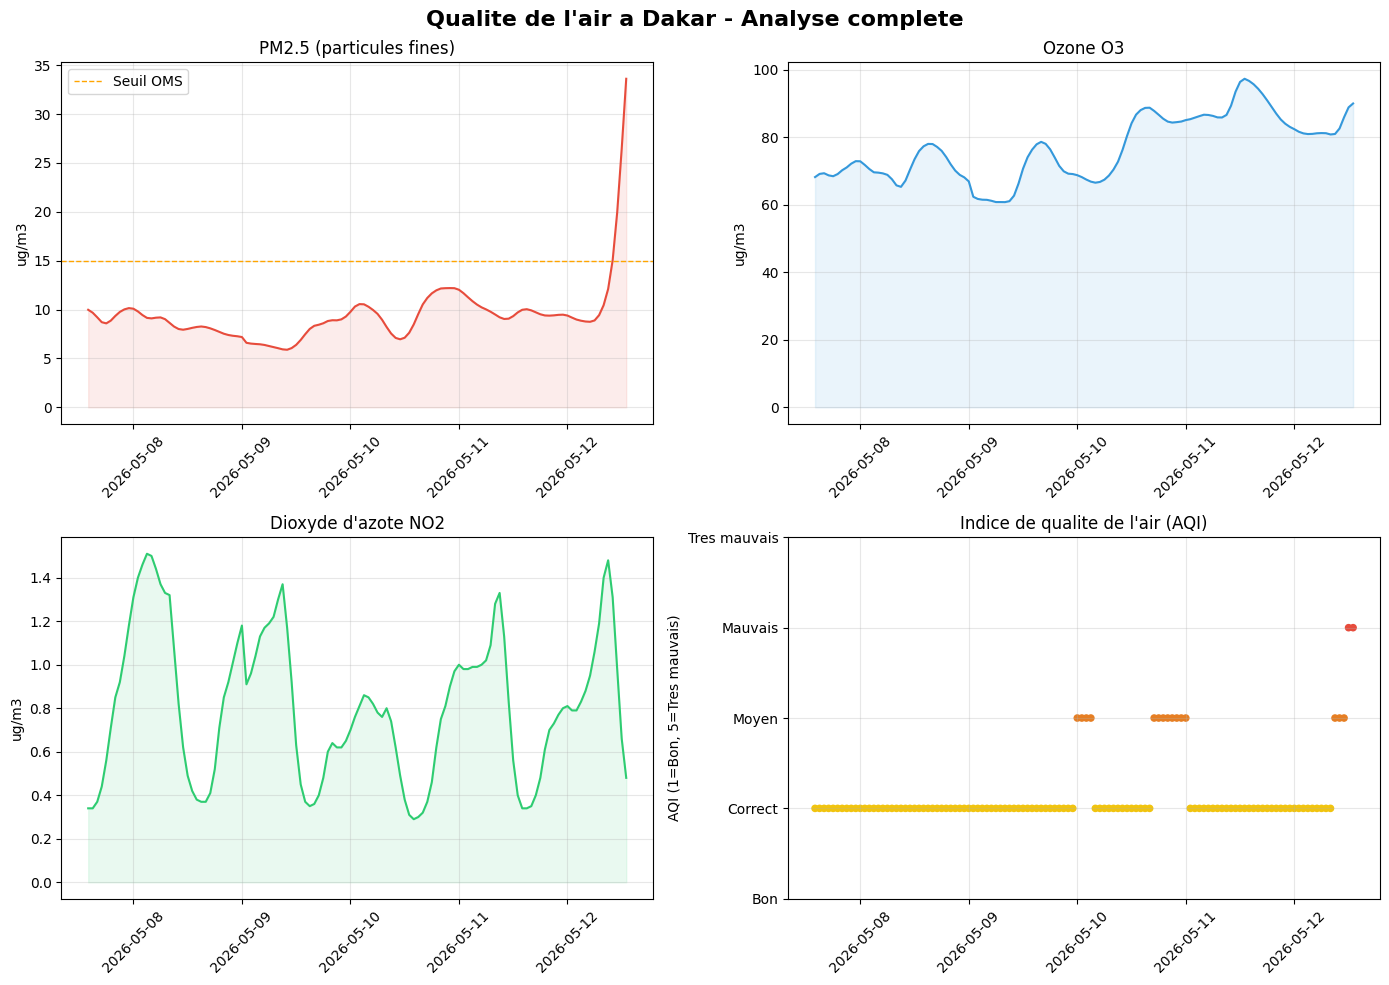

Graphique sauvegarde


In [5]:
# Cellule 5 - Graphique comparaison de tous les polluants
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Qualite de l\'air a Dakar - Analyse complete', fontsize=16, fontweight='bold')

# PM2.5
axes[0, 0].plot(df['datetime'], df['pm2_5'], color='#e74c3c', linewidth=1.5)
axes[0, 0].axhline(y=15, color='orange', linestyle='--', linewidth=1, label='Seuil OMS')
axes[0, 0].fill_between(df['datetime'], df['pm2_5'], alpha=0.1, color='#e74c3c')
axes[0, 0].set_title('PM2.5 (particules fines)')
axes[0, 0].set_ylabel('ug/m3')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Ozone
axes[0, 1].plot(df['datetime'], df['o3'], color='#3498db', linewidth=1.5)
axes[0, 1].fill_between(df['datetime'], df['o3'], alpha=0.1, color='#3498db')
axes[0, 1].set_title('Ozone O3')
axes[0, 1].set_ylabel('ug/m3')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# NO2
axes[1, 0].plot(df['datetime'], df['no2'], color='#2ecc71', linewidth=1.5)
axes[1, 0].fill_between(df['datetime'], df['no2'], alpha=0.1, color='#2ecc71')
axes[1, 0].set_title('Dioxyde d\'azote NO2')
axes[1, 0].set_ylabel('ug/m3')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# AQI
aqi_colors = {1: '#2ecc71', 2: '#f1c40f', 3: '#e67e22', 4: '#e74c3c', 5: '#8e44ad'}
colors = df['aqi'].map(aqi_colors)
axes[1, 1].scatter(df['datetime'], df['aqi'], c=colors, s=20)
axes[1, 1].set_title('Indice de qualite de l\'air (AQI)')
axes[1, 1].set_ylabel('AQI (1=Bon, 5=Tres mauvais)')
axes[1, 1].set_yticks([1, 2, 3, 4, 5])
axes[1, 1].set_yticklabels(['Bon', 'Correct', 'Moyen', 'Mauvais', 'Tres mauvais'])
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visuals/analyse_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde")

In [6]:
# Cellule 6 - Statistiques resumees
print("=" * 50)
print("RESUME DE LA QUALITE DE L'AIR A DAKAR")
print("Periode : 5 derniers jours")
print("=" * 50)

aqi_labels = {1: 'Bon', 2: 'Correct', 3: 'Moyen', 4: 'Mauvais', 5: 'Tres mauvais'}

print(f"\nPM10 moyen     : {df['pm10'].mean():.2f} ug/m3")
print(f"PM10 maximum   : {df['pm10'].max():.2f} ug/m3")
print(f"PM2.5 moyen    : {df['pm2_5'].mean():.2f} ug/m3")
print(f"PM2.5 maximum  : {df['pm2_5'].max():.2f} ug/m3")
print(f"O3 moyen       : {df['o3'].mean():.2f} ug/m3")

print(f"\nAQI le plus frequent : {aqi_labels[df['aqi'].mode()[0]]}")
print(f"Heures en qualite mauvaise ou pire : {len(df[df['aqi'] >= 4])} sur {len(df)}")
print(f"Pourcentage du temps au-dessus seuil OMS PM10 : {(len(df[df['pm10'] > 50]) / len(df) * 100):.1f}%")

print("\nSource : OpenWeatherMap Air Pollution API")
print(f"Coordonnees Dakar : 14.6937 N, 17.4441 O")

RESUME DE LA QUALITE DE L'AIR A DAKAR
Periode : 5 derniers jours

PM10 moyen     : 37.56 ug/m3
PM10 maximum   : 160.49 ug/m3
PM2.5 moyen    : 9.47 ug/m3
PM2.5 maximum  : 33.62 ug/m3
O3 moyen       : 76.85 ug/m3

AQI le plus frequent : Correct
Heures en qualite mauvaise ou pire : 2 sur 120
Pourcentage du temps au-dessus seuil OMS PM10 : 14.2%

Source : OpenWeatherMap Air Pollution API
Coordonnees Dakar : 14.6937 N, 17.4441 O
